# trial 4.5: vertical mixing with more layers and deeper coastal columns

trial 4.4 placed the enhanced-mixing box over most of the nearby amazon freshwater forcing, but salinity still became negative. the 3 by 3 spreading reduced the maximum local freshwater flux, but it did not improve the day-12 minimum salinity.

this trial removes freshwater spreading completely and uses numericalearth's normal prescribed river forcing. it keeps the localized upper-30-meter diffusivity while changing:

- vertical levels: 20 to 40
- minimum represented ocean depth: 10 m to 30 m

the purpose is to test whether more resolved wet layers and deeper coastal columns allow the vertical-mixing treatment to redistribute the native river forcing more effectively.

the total model depth remains 4000 m because increasing the deep-ocean limit would not add water at the river mouth.

In [1]:
import Pkg

Pkg.activate(".")
Pkg.instantiate()
import Pkg; Pkg.add("KernelAbstractions")

  Activating new project at `c:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\repo-cleanup\ocean-modeling\amazon_river\debugging\4\4.5`
     Project No packages added to or removed from `C:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\repo-cleanup\ocean-modeling\amazon_river\debugging\4\4.5\Project.toml`
    Manifest No packages added to or removed from `C:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\repo-cleanup\ocean-modeling\amazon_river\debugging\4\4.5\Manifest.toml`
    Updating registry at `C:\Users\meghn\.julia\registries\General.toml`
   Resolving package versions...
    Updating `C:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\repo-cleanup\ocean-modeling\amazon_river\debugging\4\4.5\Project.toml`
  [63c18a36] + KernelAbstractions v0.9.42
    Updating `C:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\repo-cleanup\ocean-modeling\amazon_river\debugging\4\4.5\Manifest.toml`
  [79e6a3ab] + Adapt v4.7.0
  [a9b

In [2]:
using NumericalEarth
using Oceananigans
using Oceananigans.Units
using Oceananigans.Grids: node
using Oceananigans.TurbulenceClosures: IsopycnalSkewSymmetricDiffusivity, AdvectiveFormulation, VerticalScalarDiffusivity, VerticallyImplicitTimeDiscretization
using Oceananigans.Architectures: architecture
using Oceananigans.Grids: inactive_node
using Oceananigans.Operators: Azá¶œá¶œáµƒ
using Oceananigans.Utils: launch!
using KernelAbstractions: @kernel, @index
using Dates
using Printf
using Statistics
using CUDA

In [3]:
# determining run version/params - :dye_test or :spinup
run_mode = :dye_test

use_rivers = true
resolution_tag = "trial4_5_nz40_mindepth30_kz0p1_no_spreading_0p1deg"

if run_mode == :dye_test
    run_days = 12
elseif run_mode == :spinup
    run_days = 360
else
    error("need right mode")
end

if use_rivers
    run_name = "rivers_on"
else
    run_name = "rivers_off"
end

if run_mode == :dye_test
    output_tag = "$(run_name)_dye_test_$(resolution_tag)"
else
    output_tag = "$(run_name)_spinup"
end

surface_filename = "amazon_$(output_tag)_surface_fields"
free_surface_filename = "amazon_$(output_tag)_free_surface"
dye_3d_filename = "amazon_$(output_tag)_dye_3d"
salinity_3d_filename = "amazon_$(output_tag)_salinity_3d"

checkpoint_filename = "amazon_$(run_name)_spinup_checkpoint.jld2"

"amazon_rivers_on_spinup_checkpoint.jld2"

In [4]:

arch = GPU()

# grid definitions -- amazon river mouth / plume region
long_west = -58.5
long_east = -41.5
lat_south = -7.8
lat_north = 9.2

Nx = 170
Ny = 170
Nz = 40

long_river = -49.5
lat_river  = 0.16

depth = 4000meters # decreased depth to 4k for this test 

z = ExponentialDiscretization(Nz, -depth, 0; scale = depth/4, mutable = false)
underlying_grid = LatitudeLongitudeGrid(
    arch;
    size = (Nx, Ny, Nz),
    halo = (5, 5, 4),
    longitude = (long_west, long_east),
    latitude = (lat_south, lat_north),
    z,
    topology = (Bounded, Bounded, Bounded)
)

minimum_ocean_depth = 30meters

bottom_height = regrid_bathymetry(underlying_grid;
                                  minimum_depth = minimum_ocean_depth,
                                  interpolation_passes = 10, 
                                  major_basins = 1) # only one major basin here -- atlantic 

grid = ImmersedBoundaryGrid(underlying_grid, GridFittedBottom(bottom_height);
                            active_cells_map=true)


                        

[ Info: Loading cached bathymetry from C:\Users\meghn\.julia\scratchspaces\904d977b-046a-4731-8b86-9235c0d1ef02\bathymetry_cache\bathymetry_170x170_-58.5_-41.5_-7.799999999999999_9.2_f6c0b31a.jld2


170Ã—170Ã—40 ImmersedBoundaryGrid{Float64, Bounded, Bounded, Bounded} on CUDAGPU with 5Ã—5Ã—4 halo:
â”œâ”€â”€ immersed_boundary: GridFittedBottom(mean(z)=-1075.17, min(z)=-4000.0, max(z)=0.0)
â”œâ”€â”€ underlying_grid: 170Ã—170Ã—40 LatitudeLongitudeGrid{Float64, Bounded, Bounded, Bounded} on CUDAGPU with 5Ã—5Ã—4 halo
â”œâ”€â”€ longitude: Bounded  Î» âˆˆ [-58.5, -41.5] regularly spaced with Î”Î»=0.1
â”œâ”€â”€ latitude:  Bounded  Ï† âˆˆ [-7.8, 9.2]    regularly spaced with Î”Ï†=0.1
â””â”€â”€ z:         Bounded  z âˆˆ [-4000.0, 0.0] variably spaced with min(Î”z)=7.84885, max(Î”z)=387.752

In [5]:

# trial 4.5 keeps the original ordinary gm/redi closure.
eddy_closure = IsopycnalSkewSymmetricDiffusivity(
    Îº_skew = 1e3,
    Îº_symmetric = 1e3,
    skew_flux_formulation = AdvectiveFormulation()
)

vertical_mixing = NumericalEarth.Oceans.default_ocean_closure()

# add extra vertical tracer mixing near the river mouth and above 30 meters
const river_mixing_longitude = -49.35
const river_mixing_latitude = -0.15
const river_mixing_kz = 0.1
const river_mixing_depth = 30meters
const river_mixing_half_width = 0.25

@inline function river_mouth_kz(longitude, latitude, z, time)
    inside_longitude = abs(longitude - river_mixing_longitude) <= river_mixing_half_width
    inside_latitude = abs(latitude - river_mixing_latitude) <= river_mixing_half_width
    inside_depth = z >= -river_mixing_depth

    if inside_longitude && inside_latitude && inside_depth
        return river_mixing_kz
    else
        return 0.0
    end
end

river_mixing = VerticalScalarDiffusivity(
    VerticallyImplicitTimeDiscretization();
    Îº = (T = river_mouth_kz,
         S = river_mouth_kz,
         dye = river_mouth_kz,
         e = 0.0)
)

closure = (eddy_closure, vertical_mixing, river_mixing)

(IsopycnalSkewSymmetricDiffusivity:
â”œâ”€â”€ Îº_skew: 1000.0
â”œâ”€â”€ Îº_symmetric: 1000.0
â”œâ”€â”€ isopycnal_tensor: Oceananigans.TurbulenceClosures.SmallSlopeIsopycnalTensor{Float64}
â””â”€â”€ slope_limiter: Oceananigans.TurbulenceClosures.FluxTapering{Float64}, CATKEVerticalDiffusivity{VerticallyImplicitTimeDiscretization}
â”œâ”€â”€ maximum_tracer_diffusivity: Inf
â”œâ”€â”€ maximum_tke_diffusivity: Inf
â”œâ”€â”€ maximum_viscosity: Inf
â”œâ”€â”€ minimum_tke: 1.0e-9
â”œâ”€â”€ negative_tke_time_scale: 60.0
â”œâ”€â”€ minimum_convective_buoyancy_flux: 1.0e-11
â”œâ”€â”€ tke_time_step: Nothing
â”œâ”€â”€ mixing_length: TKEBasedVerticalDiffusivities.CATKEMixingLength
â”‚   â”œâ”€â”€ CË¢:   1.131
â”‚   â”œâ”€â”€ Cáµ‡:   0.01
â”‚   â”œâ”€â”€ CÊ°â±u: 0.242
â”‚   â”œâ”€â”€ CÊ°â±c: 0.098
â”‚   â”œâ”€â”€ CÊ°â±e: 0.548
â”‚   â”œâ”€â”€ CË¡áµ’u: 0.361
â”‚   â”œâ”€â”€ CË¡áµ’c: 0.369
â”‚   â”œâ”€â”€ CË¡áµ’e: 7.863
â”‚   â”œâ”€â”€ Cáµ˜â¿u: 0.37
â”‚   â”œâ”€â”€ Cáµ˜â¿c: 0.572
â”‚   â”œâ”€â”€ Cáµ˜

In [6]:
free_surface = SplitExplicitFreeSurface(grid; substeps = 70)
momentum_advection = WENOVectorInvariant(order = 5)
tracer_advection = WENO(order = 5)

# create zero-gradient (Neumann) boundary conditions for dye 
# "flow out" part of the model 
dye_bcs = FieldBoundaryConditions(
    west   = GradientBoundaryCondition(0),
    east   = GradientBoundaryCondition(0),
    south  = GradientBoundaryCondition(0),
    north  = GradientBoundaryCondition(0),
    top    = FluxBoundaryCondition(0),
    bottom = FluxBoundaryCondition(0)
)

# compile tracer boundary conditions for the model
model_bcs = (
    dye = dye_bcs,
)

# updated sponge layer logic!
# summary: inital sponge was too large + errored. kept on throwing invalidIREerror. Oceanangians converts the sponge relaxation into a continuous form, which isn't compatible with the GPU, hence the error
# made a manual function creating the gaussian mask for the northern bounday, but then applied the relaxation in discrete form 

# store as gpu-accessible constant
const north_sponge_mask = GaussianMask{:y}(
    center = 9.2,
    width = 0.25
)

# store as a gpu-accessible constant
const north_sponge_rate = 1 / 5days

# apply gaussian dye relaxation in discrete form
@inline function north_dye_sponge(i, j, k, grid, clock, model_fields)
    # get the coordinates of dye cell
    x, y, z = node(i, j, k, grid, Center(), Center(), Center())

    # evaluate gaussian mask from oceaningans at this cell
    mask = north_sponge_mask(x, y, z)

    # read the local dye concentration + relax towards 0 
    dye = @inbounds model_fields.dye[i, j, k]
    return -north_sponge_rate * mask * dye

end

# use the discrete form to avoid the bug 
dye_sponge = Forcing(
    north_dye_sponge;
    discrete_form = true
)

# apply the sponge only to dye
model_forcing = (
    dye = dye_sponge,
)
                        
# dd dye with the original NumericalEarth momentum, tracer, and closure settings.
ocean = ocean_simulation(grid;
                         momentum_advection, tracer_advection, free_surface,
                         closure = closure,
                         tracers = (:T, :S, :dye),
                         boundary_conditions = model_bcs,
                         forcing = model_forcing
                         )

# instead of floating dye patch, new dye patch centered on the river mouth, fading with distance
# dye is initially deposited only in the upper 10 meters
@inline function dye_initial_condition(x, y, z)
    horizontal_width = 0.5

    horizontal_blob = exp(-((x - long_river)^2 + (y - lat_river)^2) / horizontal_width^2)

    if z > -10
        return horizontal_blob
    else
        return 0
    end
end

# print the model structure so we can check that dye is listed as a tracer and that the boundary conditions were set to 0 gradient
@info "We've built an ocean simulation with model:"
@show ocean.model
@show ocean.model.tracers.dye.boundary_conditions



ocean.model = HydrostaticFreeSurfaceModel{CUDAGPU, ImmersedBoundaryGrid}(time = 0 seconds, iteration = 0)
â”œâ”€â”€ grid: 170Ã—170Ã—40 ImmersedBoundaryGrid{Float64, Bounded, Bounded, Bounded} on CUDAGPU with 5Ã—5Ã—4 halo
â”œâ”€â”€ timestepper: SplitRungeKuttaTimeStepper
â”œâ”€â”€ tracers: (T, S, dye, e)
â”œâ”€â”€ closure: Tuple with 3 closures:
â”‚   â”œâ”€â”€ CATKEVerticalDiffusivity{VerticallyImplicitTimeDiscretization}
â”‚   â”œâ”€â”€ IsopycnalSkewSymmetricDiffusivity(Îº_skew=1000.0, Îº_symmetric=1000.0)
â”‚   â””â”€â”€ VerticalScalarDiffusivity{VerticallyImplicitTimeDiscretization}(Î½=0.0, Îº=(T=river_mouth_kz (generic function with 1 method), S=river_mouth_kz (generic function with 1 method), dye=river_mouth_kz (generic function with 1 method), e=0.0))
â”œâ”€â”€ buoyancy: SeawaterBuoyancy with g=9.80665 and BoussinesqEquationOfState{Float64} with gÌ‚ = NegativeZDirection()
â”œâ”€â”€ free surface: SplitExplicitFreeSurface with gravitational acceleration 9.80665 m sâ»Â²
â”‚   â””â”

[ Info: We've built an ocean simulation with model:


ocean.model.tracers.dye.boundary_conditions = Oceananigans.FieldBoundaryConditions, with boundary conditions
â”œâ”€â”€ west: GradientBoundaryCondition: 0.0
â”œâ”€â”€ east: GradientBoundaryCondition: 0.0
â”œâ”€â”€ south: GradientBoundaryCondition: 0.0
â”œâ”€â”€ north: GradientBoundaryCondition: 0.0
â”œâ”€â”€ bottom: FluxBoundaryCondition: 0.0
â”œâ”€â”€ top: FluxBoundaryCondition: 0.0
â””â”€â”€ immersed: FluxBoundaryCondition: Nothing


Oceananigans.FieldBoundaryConditions, with boundary conditions
â”œâ”€â”€ west: GradientBoundaryCondition: 0.0
â”œâ”€â”€ east: GradientBoundaryCondition: 0.0
â”œâ”€â”€ south: GradientBoundaryCondition: 0.0
â”œâ”€â”€ north: GradientBoundaryCondition: 0.0
â”œâ”€â”€ bottom: FluxBoundaryCondition: 0.0
â”œâ”€â”€ top: FluxBoundaryCondition: 0.0
â””â”€â”€ immersed: FluxBoundaryCondition: Nothing

In [7]:
# ask for ecco credentials at runtime so they are not saved in the notebook
if !haskey(ENV, "ECCO_USERNAME")
    ENV["ECCO_USERNAME"] = IJulia.readprompt("ecco username")
end
if !haskey(ENV, "ECCO_WEBDAV_PASSWORD")
    ENV["ECCO_WEBDAV_PASSWORD"] = IJulia.readprompt("ecco webdav password"; password = true)
end

date = DateTime(1993, 1, 1)

ecco_variables = (:temperature, :salinity)
ecco_set = MetadataSet(ecco_variables; dataset = ECCO4Monthly(), date)

# we aren't initializing the tracer just yet (first spinning-up the model for a year)  
# print out all of the tracers 
set!(ocean.model, ecco_set)
@show keys(ocean.model.tracers)

keys(ocean.model.tracers) = (:T, :S, :dye, :e)


(:T, :S, :dye, :e)

In [8]:

land = JRA55PrescribedLand(arch)
atmosphere = JRA55PrescribedAtmosphere(arch)
ocean_surface = SurfaceRadiationProperties(albedo = LatitudeDependentAlbedo())
radiation = JRA55PrescribedRadiation(arch; ocean_surface)

640Ã—320Ã—1Ã—2920 PrescribedRadiation on LatitudeLongitudeGrid:
â”œâ”€â”€ times: 2920-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
â”œâ”€â”€ stefan_boltzmann_constant: 5.67037e-8
â””â”€â”€ surface_properties: (:ocean, :sea_ice)

In [9]:
# trial 4.5 uses numericalearth's native river forcing with no custom spreading
@assert use_rivers "trial 4.5 requires use_rivers = true"
land_component = land

# build the regional ocean model
coupled_model = EarthSystemModel(
    ;
    ocean,
    atmosphere,
    land = land_component,
    radiation
)

# check the prescribed river-mouth mixing function
@assert river_mouth_kz(river_mixing_longitude, river_mixing_latitude, -10, 0) == river_mixing_kz
@assert river_mouth_kz(river_mixing_longitude, river_mixing_latitude, -40, 0) == 0.0
@info "trial 4.5 river mixing check" river_mixing_longitude river_mixing_latitude river_mixing_kz river_mixing_depth river_mixing_half_width

# timestep used for the 12-day test
time_step = 3minutes

simulation = Simulation(
    coupled_model;
    Î”t = time_step,
    stop_time = run_days * days
)

advective_cfl = AdvectiveCFL(time_step)

â”Œ Warning: 1440Ã—720Ã—1Ã—365 PrescribedLand tracks time as Float32 but the EarthSystemModel clock uses Float64; coercing the component clock to keep components synchronized.
â”” @ NumericalEarth.EarthSystemModels C:\Users\meghn\.julia\packages\NumericalEarth\eKhWQ\src\EarthSystemModels\components.jl:136
â”Œ Info: trial 4.5 river mixing check
â”‚   river_mixing_longitude = -49.35
â”‚   river_mixing_latitude = -0.15
â”‚   river_mixing_kz = 0.1
â”‚   river_mixing_depth = 30.0
â””   river_mixing_half_width = 0.25


CFL{Float64, typeof(Oceananigans.Advection.cell_advection_timescale)}(180.0, Oceananigans.Advection.cell_advection_timescale)

In [10]:
wall_time = Ref(time_ns())

function progress(sim)

    ocean = sim.model.ocean

    u, v, w = ocean.model.velocities

    T = ocean.model.tracers.T
    S = ocean.model.tracers.S
    dye = ocean.model.tracers.dye
    e = ocean.model.tracers.e

    Tmin, Tmax = minimum(T), maximum(T)
    Smin, Smax = minimum(S), maximum(S)
    dyemin, dyemax = minimum(dye), maximum(dye)
    emin, emax = minimum(e), maximum(e)
    cfl = advective_cfl(ocean.model)

    umax = (
        maximum(abs, u),
        maximum(abs, v),
        maximum(abs, w)
    )

    step_time = 1e-9 * (time_ns() - wall_time[])

    msg1 = @sprintf(
        "time: %s, iter: %d",
        prettytime(sim),
        iteration(sim)
    )

    msg2 = @sprintf(
        ", max|u|: (%.3e, %.3e, %.3e) m sâ»Â¹",
        umax[1],
        umax[2],
        umax[3]
    )

    msg3 = @sprintf(
        "\nT:    min = %.6e, max = %.6e Â°C",
        Tmin,
        Tmax
    )

    msg4 = @sprintf(
        "\nS:    min = %.6e, max = %.6e",
        Smin,
        Smax
    )

    msg5 = @sprintf(
        "\ndye:  min = %.6e, max = %.6e",
        dyemin,
        dyemax
    )

    msg6 = @sprintf(
        "\ne:    min = %.6e, max = %.6e mÂ² sâ»Â²",
        emin,
        emax
    )

    msg7 = @sprintf(
        "\nadvective CFL = %.6e",
        cfl
    )

    msg9 = @sprintf(
        "\nwall time since last report: %s\n",
        prettytime(step_time)
    )

    @info msg1 * msg2 * msg3 * msg4 * msg5 * msg6 * msg7 * msg9

    tracer_extrema = (
        Tmin, Tmax,
        Smin, Smax,
        dyemin, dyemax,
        emin, emax
    )

    if dyemin < 0
        warning_message = @sprintf(
            "NEGATIVE DYE DETECTED: min(dye) = %.6e",
            dyemin
        )
        @warn warning_message
    end

    if dyemax > 1
        warning_message = @sprintf(
            "OVERSHOOT DYE DETECTED: max(dye) = %.6e",
            dyemax
        )
        @warn warning_message
    end

    if Smin < 0
        warning_message = @sprintf(
            "NEGATIVE SALINITY DETECTED: min(S) = %.6e",
            Smin
        )
        @warn warning_message
    end

    wall_time[] = time_ns()

    return nothing
end

progress (generic function with 1 method)

In [11]:
# print the progress report every simulated day
add_callback!(simulation, progress, TimeInterval(1days))

In [12]:
# collect surface tracers + velocities
ocean_outputs = merge(
    ocean.model.tracers,
    ocean.model.velocities
)

# collect full 3d salinity
salinity_output = (
    S = ocean.model.tracers.S,
)

# grab the free-surface displacement
free_surface = ocean.model.free_surface.displacement

# save daily surface tracers + velocities in both modes
ocean.output_writers[:surface] = JLD2Writer(
    ocean.model,
    ocean_outputs;
    schedule = TimeInterval(1days),
    filename = surface_filename,
    indices = (:, :, grid.Nz),
    overwrite_existing = true
)

# save daily sea-surface height in both modes
ocean.output_writers[:free_surface] = JLD2Writer(
    ocean.model,
    (; Î· = free_surface);
    schedule = TimeInterval(1days),
    filename = free_surface_filename,
    overwrite_existing = true
)

if run_mode == :dye_test
    dye_output = (
        dye = ocean.model.tracers.dye,
    )

    # save full 3d dye daily for the 5-day test
    ocean.output_writers[:dye_3d] = JLD2Writer(
        ocean.model,
        dye_output;
        schedule = TimeInterval(1days),
        filename = dye_3d_filename,
        overwrite_existing = true
    )

    # save full 3d salinity daily for the short test
    ocean.output_writers[:salinity_3d] = JLD2Writer(
        ocean.model,
        salinity_output;
        schedule = TimeInterval(1days),
        filename = salinity_3d_filename,
        overwrite_existing = true
    )

elseif run_mode == :spinup
    # do not save 3d dye because it remains zero during spin-up

    # save full 3d salinity every 30 days during spin-up
    ocean.output_writers[:salinity_3d] = JLD2Writer(
        ocean.model,
        salinity_output;
        schedule = TimeInterval(30days),
        filename = salinity_3d_filename,
        overwrite_existing = true
    )

    # save a restart checkpoint every 30 days
    simulation.output_writers[:checkpointer] = Checkpointer(
        simulation.model;
        schedule = TimeInterval(30days),
        prefix = "amazon_$(run_name)_spinup_checkpoint",
        cleanup = true,
        overwrite_existing = true
    )
end

JLD2Writer scheduled on TimeInterval(1 day):
â”œâ”€â”€ filepath: amazon_rivers_on_dye_test_trial4_5_nz40_mindepth30_kz0p1_no_spreading_0p1deg_salinity_3d.jld2
â”œâ”€â”€ 1 outputs: S
â”œâ”€â”€ array_type: Array{Float32}
â”œâ”€â”€ including: [:coriolis, :buoyancy, :closure]
â”œâ”€â”€ file_splitting: NoFileSplitting
â””â”€â”€ file size: 0 bytes (file not yet created)

In [13]:
# confirm the trial 4.5 configuration before starting the long run
@assert resolution_tag == "trial4_5_nz40_mindepth30_kz0p1_no_spreading_0p1deg"
@assert use_rivers
@assert grid.Nz == 40
@assert minimum_ocean_depth == 30meters
@assert river_mixing_longitude == -49.35
@assert river_mixing_latitude == -0.15
@assert river_mixing_half_width == 0.25
@assert river_mixing_depth == 30meters
@assert river_mixing_kz == 0.1
@assert iteration(simulation) == 0 "build a new simulation before starting trial 4.5"
@info "trial 4.5 pre-run check passed" grid.Nz minimum_ocean_depth river_mixing_longitude river_mixing_latitude river_mixing_half_width river_mixing_depth river_mixing_kz

if run_mode == :dye_test
    set!(ocean.model, dye = dye_initial_condition)

    @show minimum(ocean.model.tracers.dye)
    @show maximum(ocean.model.tracers.dye)

    @info "initial values right after dye is deposited:"
    progress(simulation)

elseif run_mode == :spinup
    set!(ocean.model, dye = 0.0)

    @info "spinup has 0 dye."
    @show minimum(ocean.model.tracers.dye)
    @show maximum(ocean.model.tracers.dye)
end

run!(simulation)

â”Œ Info: trial 4.5 pre-run check passed
â”‚   grid.Nz = 40
â”‚   minimum_ocean_depth = 30.0
â”‚   river_mixing_longitude = -49.35
â”‚   river_mixing_latitude = -0.15
â”‚   river_mixing_half_width = 0.25
â”‚   river_mixing_depth = 30.0
â””   river_mixing_kz = 0.1


minimum(ocean.model.tracers.dye) = 0.0
maximum(ocean.model.tracers.dye) = 0.9896538930090968


[ Info: initial values right after dye is deposited:
â”Œ Info: time: 0 seconds, iter: 0, max|u|: (0.000e+00, 0.000e+00, 0.000e+00) m sâ»Â¹
â”‚ T:    min = 2.008900e+00, max = 2.821791e+01 Â°C
â”‚ S:    min = 3.086353e+01, max = 3.669036e+01
â”‚ dye:  min = 0.000000e+00, max = 9.896539e-01
â”‚ e:    min = 0.000000e+00, max = 0.000000e+00 mÂ² sâ»Â²
â”‚ advective CFL = 0.000000e+00
â”” wall time since last report: 1.743 minutes
[ Info: Initializing simulation...
â”Œ Info: time: 0 seconds, iter: 0, max|u|: (0.000e+00, 0.000e+00, 0.000e+00) m sâ»Â¹
â”‚ T:    min = 2.008900e+00, max = 2.821791e+01 Â°C
â”‚ S:    min = 3.086353e+01, max = 3.669036e+01
â”‚ dye:  min = 0.000000e+00, max = 9.896539e-01
â”‚ e:    min = 0.000000e+00, max = 0.000000e+00 mÂ² sâ»Â²
â”‚ advective CFL = 0.000000e+00
â”” wall time since last report: 24.246 seconds
[ Info:     ... simulation initialization complete (4.779 seconds)
[ Info: Executing initial time step...
[ Info:     ... initial time step complete (6.016

In [14]:

# add the file extension used by fieldtimeseries
surface_filepath = surface_filename * ".jld2"
free_surface_filepath = free_surface_filename * ".jld2"
dye_3d_filepath = dye_3d_filename * ".jld2"
salinity_3d_filepath = salinity_3d_filename * ".jld2"

# load daily surface fields
uo = FieldTimeSeries(surface_filepath, "u"; backend = OnDisk())
vo = FieldTimeSeries(surface_filepath, "v"; backend = OnDisk())
To = FieldTimeSeries(surface_filepath, "T"; backend = OnDisk())
So = FieldTimeSeries(surface_filepath, "S"; backend = OnDisk())
eo = FieldTimeSeries(surface_filepath, "e"; backend = OnDisk())
dye = FieldTimeSeries(surface_filepath, "dye"; backend = OnDisk())
Î·o = FieldTimeSeries(free_surface_filepath, "Î·"; backend = OnDisk())

# load full 3d dye saved daily
dye_3d = FieldTimeSeries(dye_3d_filepath, "dye"; backend = OnDisk())
# load full 3d salinity saved every 5 days
S_3d = FieldTimeSeries(salinity_3d_filepath, "S"; backend = OnDisk())

# check the output times + dimensions
@show length(So.times)
@show So.times ./ days
@show length(dye_3d.times)
@show dye_3d.times ./ days
@show length(S_3d.times)
@show S_3d.times ./ days
@show size(interior(dye_3d[1]))
@show size(interior(S_3d[1]))

length(So.times) = 13
So.times ./ days = 0.0:1.0:12.0
length(dye_3d.times) = 13
dye_3d.times ./ days = 0.0:1.0:12.0
length(S_3d.times) = 13
S_3d.times ./ days = 0.0:1.0:12.0
size(interior(dye_3d[1])) = (170, 170, 40)
size(interior(S_3d[1])) = (170, 170, 40)


(170, 170, 40)

In [15]:

using CairoMakie

times = To.times
Nt = minimum((length(uo.times), length(vo.times), length(To.times), length(So.times), length(eo.times), length(dye.times), length(Î·o.times)))
n = Observable(1)

Observable(1)


In [16]:
# land mask from bathymetry
land_full = interior(To.grid.immersed_boundary.bottom_height) .â‰¥ 0

Toâ‚™ = @lift begin
    Tâ‚™ = Array(interior(To[$n]))

    land = falses(size(Tâ‚™))
    i = min(size(Tâ‚™, 1), size(land_full, 1))
    j = min(size(Tâ‚™, 2), size(land_full, 2))
    k = min(size(Tâ‚™, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    Tâ‚™[land] .= NaN
    view(Tâ‚™, :, :, 1)
end

eoâ‚™ = @lift begin
    eâ‚™ = Array(interior(eo[$n]))

    land = falses(size(eâ‚™))
    i = min(size(eâ‚™, 1), size(land_full, 1))
    j = min(size(eâ‚™, 2), size(land_full, 2))
    k = min(size(eâ‚™, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    eâ‚™[land] .= NaN
    view(eâ‚™, :, :, 1)
end

Î·oâ‚™ = @lift begin
    Î·â‚™ = Array(interior(Î·o[$n]))

    land = falses(size(Î·â‚™))
    i = min(size(Î·â‚™, 1), size(land_full, 1))
    j = min(size(Î·â‚™, 2), size(land_full, 2))
    k = min(size(Î·â‚™, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    Î·â‚™[land] .= NaN
    view(Î·â‚™, :, :, 1)
end

uoâ‚™ = Field{Face, Center, Nothing}(uo.grid)
voâ‚™ = Field{Center, Face, Nothing}(vo.grid)
so = Field(sqrt(uoâ‚™^2 + voâ‚™^2))

soâ‚™ = @lift begin
    parent(uoâ‚™) .= parent(uo[$n])
    parent(voâ‚™) .= parent(vo[$n])
    compute!(so)

    sâ‚™ = Array(interior(so))

    land = falses(size(sâ‚™))
    i = min(size(sâ‚™, 1), size(land_full, 1))
    j = min(size(sâ‚™, 2), size(land_full, 2))
    k = min(size(sâ‚™, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    sâ‚™[land] .= NaN
    view(sâ‚™, :, :, 1)
end

dyeâ‚™ = @lift begin
    d = Array(interior(dye[$n]))

    land = falses(size(d))
    i = min(size(d, 1), size(land_full, 1))
    j = min(size(d, 2), size(land_full, 2))
    k = min(size(d, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    d[land] .= NaN
    d_log = log10.(max.(d, 0) .+ 1e-16)

    view(d_log, :, :, 1)
end

Soâ‚™ = @lift begin
    Sâ‚™ = Array(interior(So[$n]))

    land = falses(size(Sâ‚™))
    i = min(size(Sâ‚™, 1), size(land_full, 1))
    j = min(size(Sâ‚™, 2), size(land_full, 2))
    k = min(size(Sâ‚™, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    Sâ‚™[land] .= NaN
    view(Sâ‚™, :, :, 1)
end

Observable(Float32[NaN NaN â€¦ 35.684647 35.706287; NaN NaN â€¦ 35.684643 35.706287; â€¦ ; NaN NaN â€¦ 36.000378 35.991276; NaN NaN â€¦ 36.00038 35.991276])


In [17]:
fig = Figure(size = (1200, 1600))

title = @lift string("amazon river snapshot ", prettytime(times[$n] - times[1]))

axso = Axis(fig[1, 1])
axÎ·o = Axis(fig[1, 3])
axTo = Axis(fig[2, 1])
axeo = Axis(fig[2, 3])
axdye = Axis(fig[3, 1])
axSo = Axis(fig[3, 3])

hm = heatmap!(axso, soâ‚™, colorrange = (0, 0.25), colormap = :deep, nan_color = :lightgray)
Colorbar(fig[1, 2], hm, label = "Ocean Surface Speed (m sâ»Â¹)")

hm = heatmap!(axÎ·o, Î·oâ‚™, colorrange = (-.1, .5), colormap = :balance, nan_color = :lightgray)
Colorbar(fig[1, 4], hm, label = "Sea Surface Height (m)")

hm = heatmap!(axTo, Toâ‚™, colorrange = (26, 32), colormap = :magma, nan_color = :lightgray)
Colorbar(fig[2, 2], hm, label = "Surface Temperature (áµ’C)")

hm = heatmap!(axeo, eoâ‚™, colorrange = (0, 3e-4), colormap = :solar, nan_color = :lightgray)
Colorbar(fig[2, 4], hm, label = "Turbulent Kinetic Energy (mÂ² sâ»Â²)")

hm = heatmap!(axdye, dyeâ‚™, colorrange = (-8, 0), colormap = :viridis, nan_color = :lightgray)
Colorbar(fig[3, 2], hm, label = "logâ‚â‚€(passive dye + 1e-16)")

hm = heatmap!(axSo, Soâ‚™, colorrange = (32, 37), colormap = :haline, nan_color = :lightgray)
Colorbar(fig[3, 4], hm, label = "Surface Salinity (g kg^-1)")

for ax in (axso, axÎ·o, axTo, axeo, axdye, axSo)
    hidedecorations!(ax)
end

Label(fig[0, :], title)


# update img to be the last saved timestep
n[] = Nt

save("amazon_salinity_$(run_name)_snapshot.png", fig)

In [18]:
CairoMakie.record(fig, "amazon_salinity_$(run_name).mp4", 1:Nt; framerate = 8) do nn
    n[] = nn
end

"amazon_salinity_rivers_on.mp4"

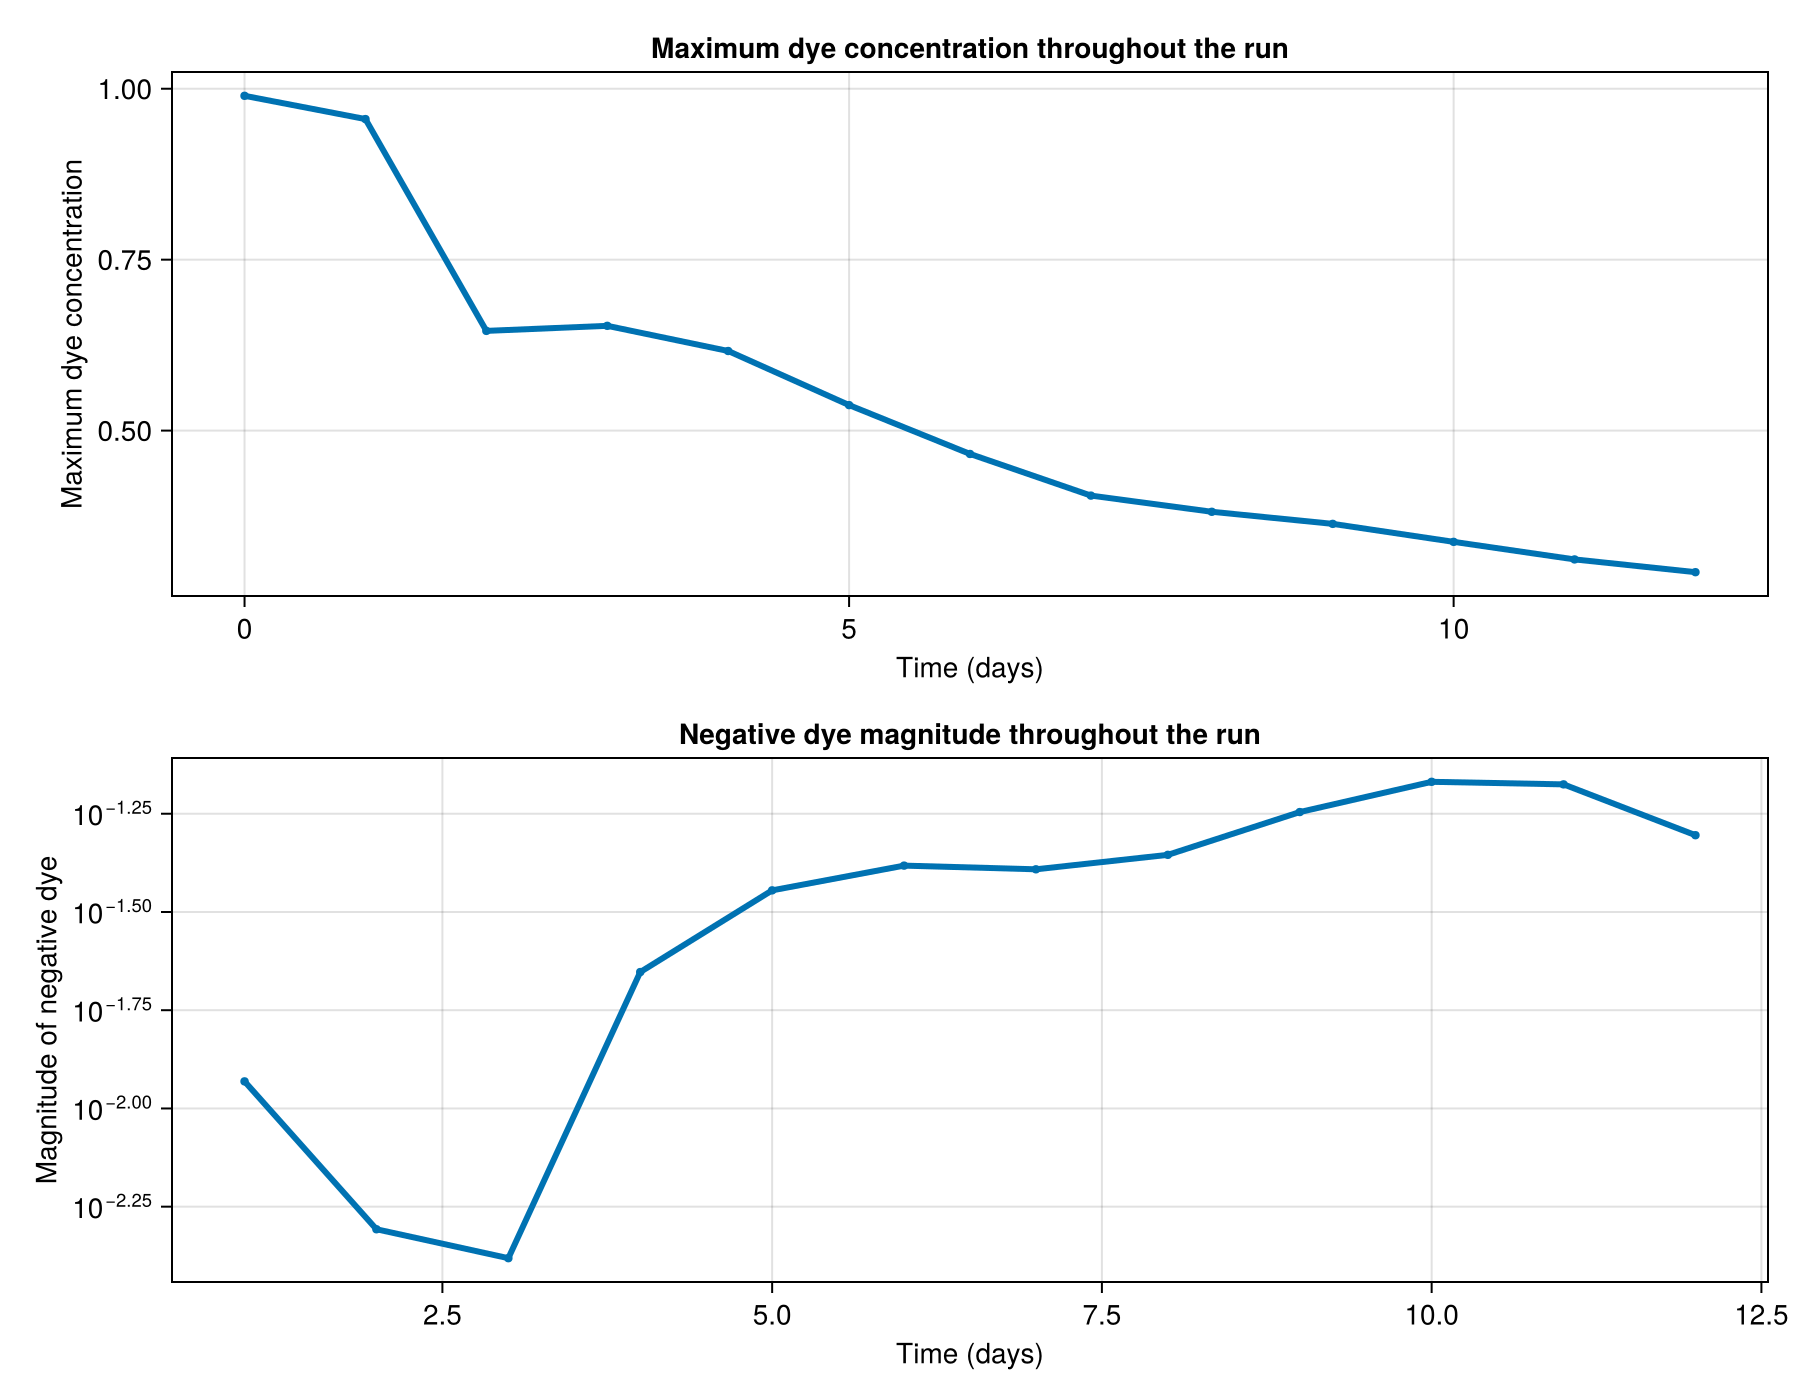

In [19]:
using Oceananigans
using CairoMakie

# load the saved 3d dye output
dye_series = FieldTimeSeries(dye_3d_filename, "dye")

Nt = length(dye_series.times)

time_days = dye_series.times ./ days
minimum_dye = zeros(Float64, Nt)
maximum_dye = zeros(Float64, Nt)

for n in 1:Nt
    dye_snapshot = Array(interior(dye_series[n]))

    minimum_dye[n] = minimum(dye_snapshot)
    maximum_dye[n] = maximum(dye_snapshot)
end

# magnitude of the negative dye values
negative_dye_amount = max.(-minimum_dye, 0)

fig = Figure(size = (900, 700))

ax1 = Axis(
    fig[1, 1],
    xlabel = "Time (days)",
    ylabel = "Maximum dye concentration",
    title = "Maximum dye concentration throughout the run"
)

lines!(
    ax1,
    time_days,
    maximum_dye;
    linewidth = 3
)

scatter!(
    ax1,
    time_days,
    maximum_dye;
    markersize = 6
)

ax2 = Axis(
    fig[2, 1],
    xlabel = "Time (days)",
    ylabel = "Magnitude of negative dye",
    title = "Negative dye magnitude throughout the run",
    yscale = log10
)

# avoid plotting exact zeros on a logarithmic axis
positive_negative_indices = findall(negative_dye_amount .> 0)

lines!(
    ax2,
    time_days[positive_negative_indices],
    negative_dye_amount[positive_negative_indices];
    linewidth = 3
)

scatter!(
    ax2,
    time_days[positive_negative_indices],
    negative_dye_amount[positive_negative_indices];
    markersize = 6
)

save("amazon_$(output_tag)_dye_extrema.png", fig)

fig